# OTF Scan Plan

Plan a simple raster scan in galactic coordinates.
Check alt/az limits at the planned observation time and visualize coverage.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import astropy.units as u
import astropy.coordinates as ac
from astropy.time import Time, TimeDelta

%matplotlib inline
plt.rcParams.update({"figure.dpi": 140, "figure.facecolor": "white"})

# Leuschner Observatory
LEO_LAT, LEO_LON, LEO_ALT = 37.9183, -122.1067, 304.0
location = ac.EarthLocation(lat=LEO_LAT * u.deg, lon=LEO_LON * u.deg,
                            height=LEO_ALT * u.m)

## 0. Project footprints (Mollweide)

All candidate survey regions overlaid on a galactic Mollweide projection,
with existing DR coverage shown.

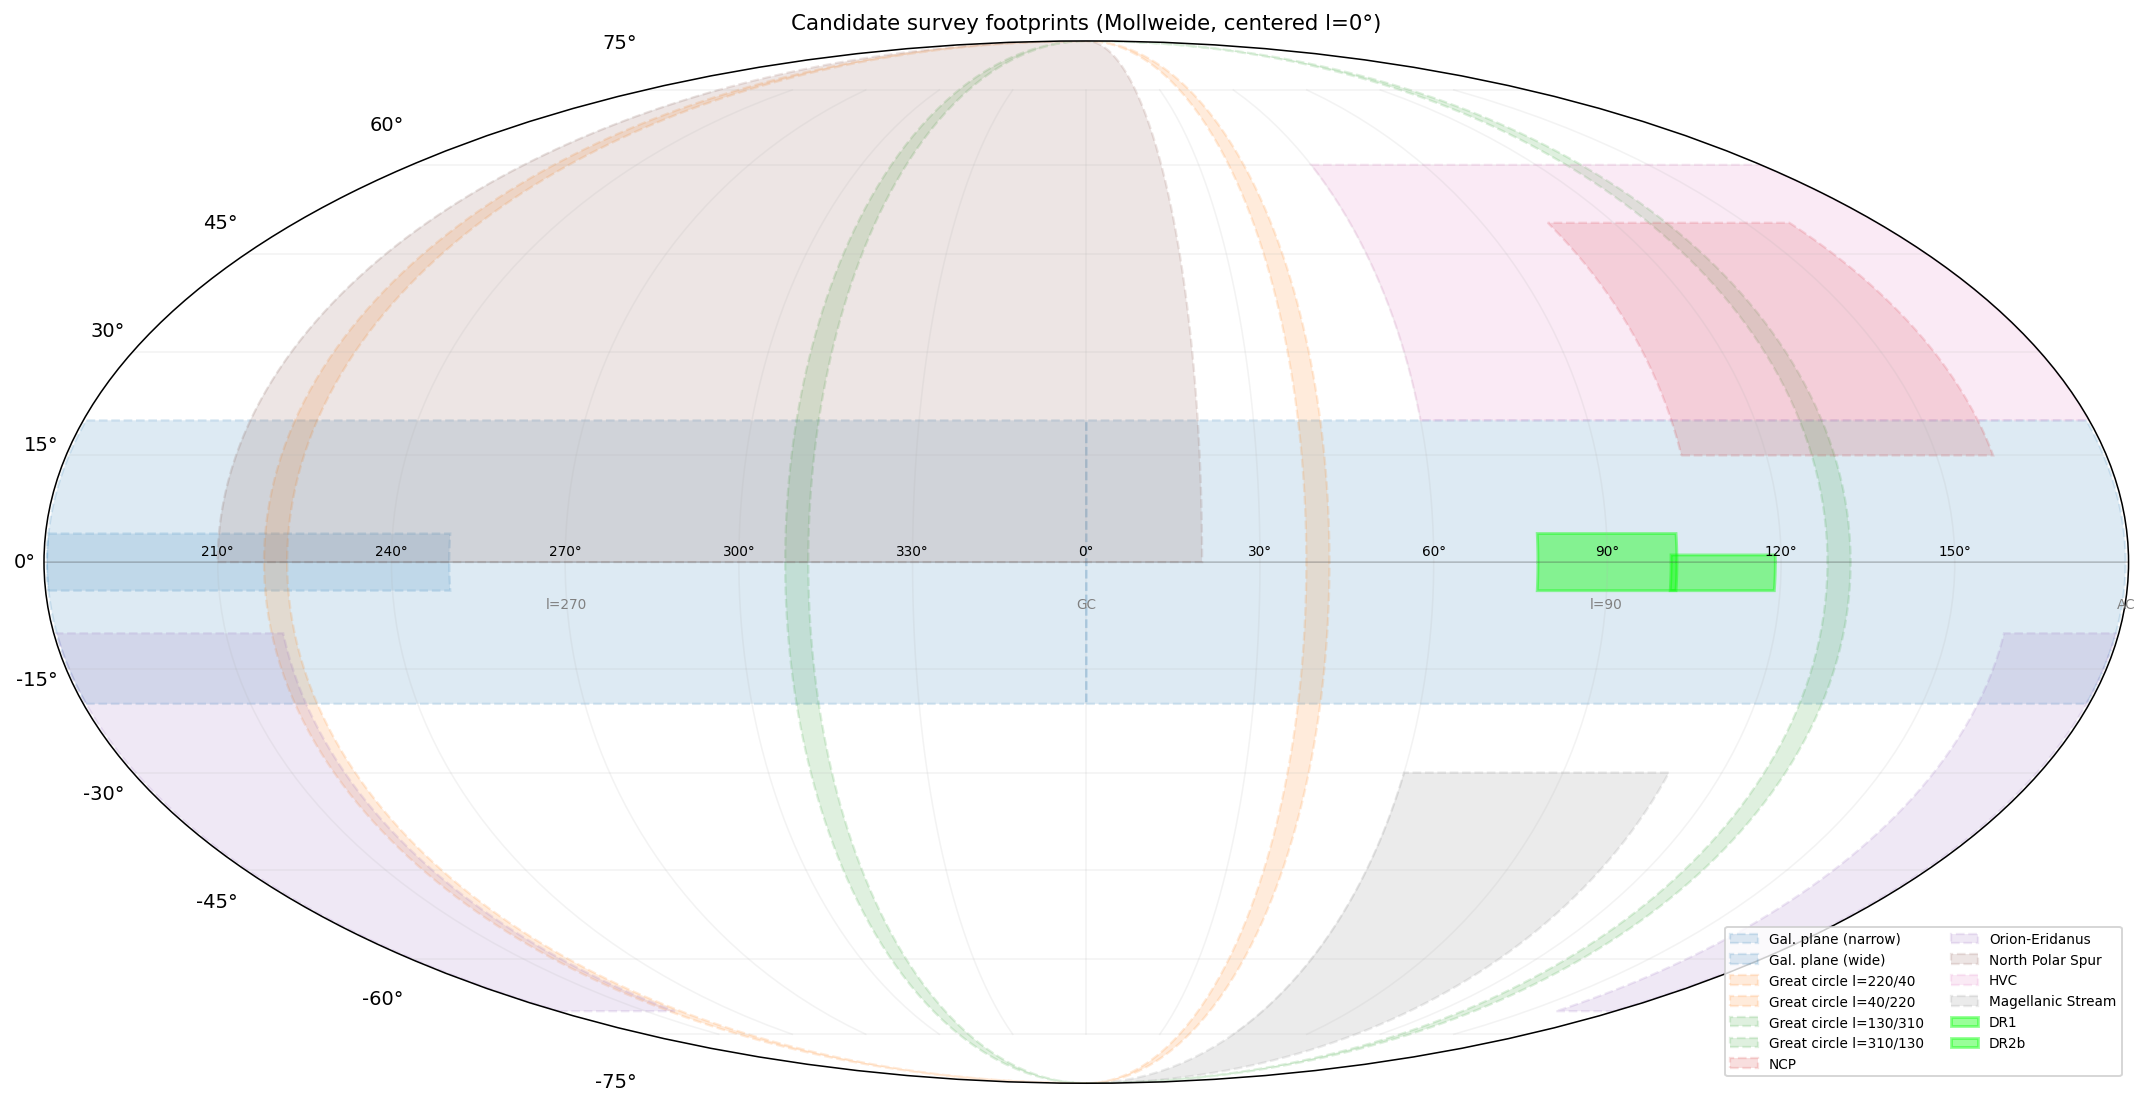

Project                        l range        b range        Area (deg²) Cells (2°)
--------------------------------------------------------------------------------
Gal. plane (narrow)            [-10,250]     [ -4, +4]         2080        520
Gal. plane (wide)              [  0,360]     [-20,+20]        14400       3600
Great circle l=220/40          [218,222]     [-90,+90]          720        180
Great circle l=130/310         [128,132]     [-90,+90]          720        180
NCP                            [105,160]     [+15,+50]         1624        459
Orion-Eridanus                 [160,220]     [-70,-10]         2758        900
North Polar Spur               [210, 20]     [ +0,+90]        10819       3825
HVC                            [ 60,180]     [+20,+60]         3677       1200
Magellanic Stream              [ 60,110]     [-90,-30]         1500        750


In [2]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

MOLL_CENTER = 0.0
MOLL_SEAM = (MOLL_CENTER + 180) % 360  # l=180 is the seam

# --- Define candidate survey footprints ---
# Each: (name, l_min, l_max, b_min, b_max, color)
# l ranges use true galactic longitude. Regions crossing the seam
# or spanning >=360° are auto-split below.
projects_raw = [
    ('Gal. plane (narrow)',     -10, 250,   -4,   4, 'C0'),
    ('Gal. plane (wide)',         0, 360,  -20,  20, 'C0'),
    ('Great circle l=220/40',   218, 222,  -90,  90, 'C1'),
    ('Great circle l=40/220',    38,  42,  -90,  90, 'C1'),
    ('Great circle l=130/310',  128, 132,  -90,  90, 'C2'),
    ('Great circle l=310/130',  308, 312,  -90,  90, 'C2'),
    ('NCP',                     105, 160,   15,  50, 'C3'),
    ('Orion-Eridanus',          160, 220,  -70, -10, 'C4'),
    ('North Polar Spur',        210, 380,    0,  90, 'C5'),  # 380 = 20+360
    ('HVC',                      60, 180,   20,  60, 'C6'),
    ('Magellanic Stream',        60, 110,  -90, -30, 'C7'),
]

def normalize_l(l):
    return l % 360

def crosses_seam(l_min, l_max):
    """Check if [l_min, l_max] crosses MOLL_SEAM."""
    span = l_max - l_min
    if span >= 360:
        return True
    lmin_n = normalize_l(l_min)
    lmax_n = normalize_l(l_max)
    if lmin_n <= lmax_n:
        return lmin_n < MOLL_SEAM < lmax_n
    else:
        return MOLL_SEAM > lmin_n or MOLL_SEAM < lmax_n

# Auto-split at seam
projects = []
for name, l_min, l_max, b_min, b_max, color in projects_raw:
    if l_max - l_min >= 360:
        # Full circle: split into two halves at seam
        projects.append((name, MOLL_SEAM + 0.5, MOLL_SEAM + 180, b_min, b_max, color))
        projects.append((name, MOLL_SEAM + 180, MOLL_SEAM + 359.5, b_min, b_max, color))
    elif crosses_seam(l_min, l_max):
        projects.append((name, l_min, MOLL_SEAM - 0.5, b_min, b_max, color))
        projects.append((name, MOLL_SEAM + 0.5, l_max, b_min, b_max, color))
    else:
        projects.append((name, l_min, l_max, b_min, b_max, color))

# Existing coverage from DRs
existing_regions = [
    ('DR1',  78, 102, -4,  4, 'white'),
    ('DR2a', 177, 183, 28, 29, 'white'),
    ('DR2b', 101, 119, -4,  1, 'white'),
]

def wrap_l(l):
    """Shift galactic l so MOLL_CENTER maps to 0, wrap to [-180, 180]."""
    l = l - MOLL_CENTER
    if l > 180: l -= 360
    if l < -180: l += 360
    return l

def make_rect_patch(l_min, l_max, b_min, b_max):
    """Create a rectangle in Mollweide coords."""
    n = 50
    wl_min, wl_max = wrap_l(l_min), wrap_l(l_max)

    if abs(wl_max - wl_min) > 180:
        return None

    l_bot = np.linspace(wl_min, wl_max, n)
    l_top = np.linspace(wl_max, wl_min, n)
    b_left = np.linspace(b_min, b_max, n)
    b_right = np.linspace(b_max, b_min, n)

    ls = np.concatenate([l_bot, np.full(n, wl_max), l_top, np.full(n, wl_min)])
    bs = np.concatenate([np.full(n, b_min), b_left, np.full(n, b_max), b_right])
    return np.column_stack([np.deg2rad(ls), np.deg2rad(bs)])

fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(111, projection='mollweide')
ax.grid(True, alpha=0.15)

# Galactic plane
l_line = np.linspace(-np.pi, np.pi, 500)
ax.plot(l_line, np.zeros_like(l_line), 'k-', lw=0.5, alpha=0.3)

# Plot each project footprint
plotted_labels = set()
for name, l_min, l_max, b_min, b_max, color in projects:
    verts = make_rect_patch(l_min, l_max, b_min, b_max)
    if verts is not None:
        label = name if name not in plotted_labels else None
        poly = plt.Polygon(verts, alpha=0.15, facecolor=color, edgecolor=color,
                          lw=1.2, linestyle='--', label=label)
        ax.add_patch(poly)
        if label:
            plotted_labels.add(name)

# Plot existing DR coverage as filled
for name, l_min, l_max, b_min, b_max, color in existing_regions:
    verts = make_rect_patch(l_min, l_max, b_min, b_max)
    if verts is not None:
        poly = plt.Polygon(verts, alpha=0.4, facecolor='lime', edgecolor='lime',
                          lw=1.5, label=name)
        ax.add_patch(poly)

# Tick labels — standard galactic convention: l increases to the left
tick_locs = np.arange(-150, 180, 30)
tick_labels = [f'{int((t + MOLL_CENTER) % 360)}°' for t in tick_locs]
ax.set_xticks(np.deg2rad(tick_locs))
ax.set_xticklabels(tick_labels, fontsize=7)

# Reference labels
for ld, name in [(0, 'GC'), (90, 'l=90'), (180, 'AC'), (270, 'l=270')]:
    lp = wrap_l(ld)
    if -180 <= lp <= 180:
        ax.annotate(name, (np.deg2rad(lp), np.deg2rad(-5)),
                    fontsize=7, ha='center', va='top', color='gray')

ax.set_title(f'Candidate survey footprints (Mollweide, centered l={MOLL_CENTER:.0f}°)',
             fontsize=11)
ax.legend(fontsize=7, loc='lower right', ncol=2)
fig.tight_layout()
plt.show()

# Summary table
summary_projects = [
    ('Gal. plane (narrow)',     -10, 250,   -4,   4),
    ('Gal. plane (wide)',         0, 360,  -20,  20),
    ('Great circle l=220/40',   218, 222,  -90,  90),
    ('Great circle l=130/310',  128, 132,  -90,  90),
    ('NCP',                     105, 160,   15,  50),
    ('Orion-Eridanus',          160, 220,  -70, -10),
    ('North Polar Spur',        210, 380,    0,  90),
    ('HVC',                      60, 180,   20,  60),
    ('Magellanic Stream',        60, 110,  -90, -30),
]
print(f'{"Project":<30} {"l range":<14} {"b range":<14} {"Area (deg²)":>10} {"Cells (2°)":>10}')
print('-' * 80)
for name, l_min, l_max, b_min, b_max in summary_projects:
    dl = l_max - l_min
    db = b_max - b_min
    b_mid = (b_max + b_min) / 2
    area = dl * db * np.cos(np.deg2rad(b_mid))
    n_cells = int(dl / 2) * int(db / 2)
    l_max_disp = l_max if l_max <= 360 else l_max - 360
    print(f'{name:<30} [{l_min:>3},{l_max_disp:>3}]     [{b_min:>+3},{b_max:>+3}]     {area:>8.0f}   {n_cells:>8}')

## 1. Scan configuration

In [ ]:
# --- DR3 Survey: two parts, 2° spacing ---
SURVEY_PARTS = [
    {
        'name': 'Part 2: Galactic plane (run first)',
        'l_min': 120, 'l_max': 180,
        'b_min':  -4, 'b_max':   4,
        'step': 2,
        'dumps_per_band': 4,
    },
    {
        'name': 'Part 1: Orion-Eridanus / wide plane',
        'l_min': 160, 'l_max': 220,
        'b_min': -20, 'b_max': -10,
        'step': 2,
        'dumps_per_band': 4,
    },
]

# --- Hardware ---
HPBW_DEG       = 3.4
NBLOCKS        = 1025
NSAMPLES       = 32768
SAMPLE_RATE    = 2.56e6
MIN_ALT_DEG    = 17.0
AZ_MIN, AZ_MAX = 7.0, 348.0

DUMP_CADENCE_S = NBLOCKS * NSAMPLES / SAMPLE_RATE + 1.5
SLEW_TIME_S    = 5.0

# --- Observation timing ---
T_START = Time.now()

total_cells = 0
total_h = 0
for part in SURVEY_PARTS:
    n_l = len(range(part['l_min'], part['l_max'] + 1, part['step']))
    n_b = len(range(part['b_min'], part['b_max'] + 1, part['step']))
    n = n_l * n_b
    dpc = part['dumps_per_band'] * 2
    cell_time = dpc * DUMP_CADENCE_S + SLEW_TIME_S
    t_h = n * cell_time / 3600
    total_cells += n
    total_h += t_h
    print(f'{part["name"]}:')
    print(f'  l=[{part["l_min"]}, {part["l_max"]}], b=[{part["b_min"]}, {part["b_max"]}], step={part["step"]}°')
    print(f'  {n_l} x {n_b} = {n} cells, {t_h:.1f}h')
    print()

print(f'Total: {total_cells} cells, {total_h:.1f}h')
print(f'Start: {T_START.iso} UTC')

## 2. Build grid and check visibility

In [ ]:
# Simulate both survey parts sequentially
sim = []
t_current = T_START

for part in SURVEY_PARTS:
    l_vals = list(range(part['l_min'], part['l_max'] + 1, part['step']))
    b_vals = list(range(part['b_min'], part['b_max'] + 1, part['step']))
    dpc = part['dumps_per_band'] * 2
    cell_dwell = dpc * DUMP_CADENCE_S
    cell_time = cell_dwell + SLEW_TIME_S

    print(f'{part["name"]}:')

    for row_idx, b in enumerate(b_vals):
        row = [(row_idx, j, l_vals[j], b) for j in range(len(l_vals))]
        if row_idx % 2 == 0:
            row = list(reversed(row))  # decreasing l

        for idx_in_row, (ri, ci, cell_l, cell_b) in enumerate(row):
            t_mid = t_current + TimeDelta(cell_dwell / 2, format='sec')
            gc = ac.SkyCoord(l=cell_l * u.deg, b=cell_b * u.deg, frame='galactic')
            icrs = gc.transform_to(ac.ICRS())
            altaz = gc.transform_to(ac.AltAz(obstime=t_mid, location=location))
            alt, az = altaz.alt.deg, altaz.az.deg
            bad = alt < MIN_ALT_DEG or alt > 83 or az < AZ_MIN or az > AZ_MAX
            sim.append({
                'idx': len(sim), 'part': part['name'],
                'l': cell_l, 'b': cell_b,
                'alt': alt, 'az': az,
                'ra': icrs.ra.deg, 'dec': icrs.dec.deg,
                'time': t_mid, 'bad': bad,
            })
            t_current += TimeDelta(cell_time, format='sec')

    part_sim = [s for s in sim if s['part'] == part['name']]
    n_bad = sum(1 for s in part_sim if s['bad'])
    alts_p = [s['alt'] for s in part_sim]
    azs_p = [s['az'] for s in part_sim]
    dur_h = len(part_sim) * cell_time / 3600
    print(f'  {len(part_sim)} cells, {dur_h:.1f}h')
    print(f'  Alt: {min(alts_p):.1f}–{max(alts_p):.1f}, Az: {min(azs_p):.1f}–{max(azs_p):.1f}')
    if n_bad:
        print(f'  WARNING: {n_bad} cells outside limits!')
    else:
        print(f'  All cells within limits.')
    print()

alts = [s['alt'] for s in sim]
azs = [s['az'] for s in sim]
n_bad_total = sum(1 for s in sim if s['bad'])
print(f'Total: {len(sim)} cells, {n_bad_total} outside limits')

## 3. Visualize scan pattern

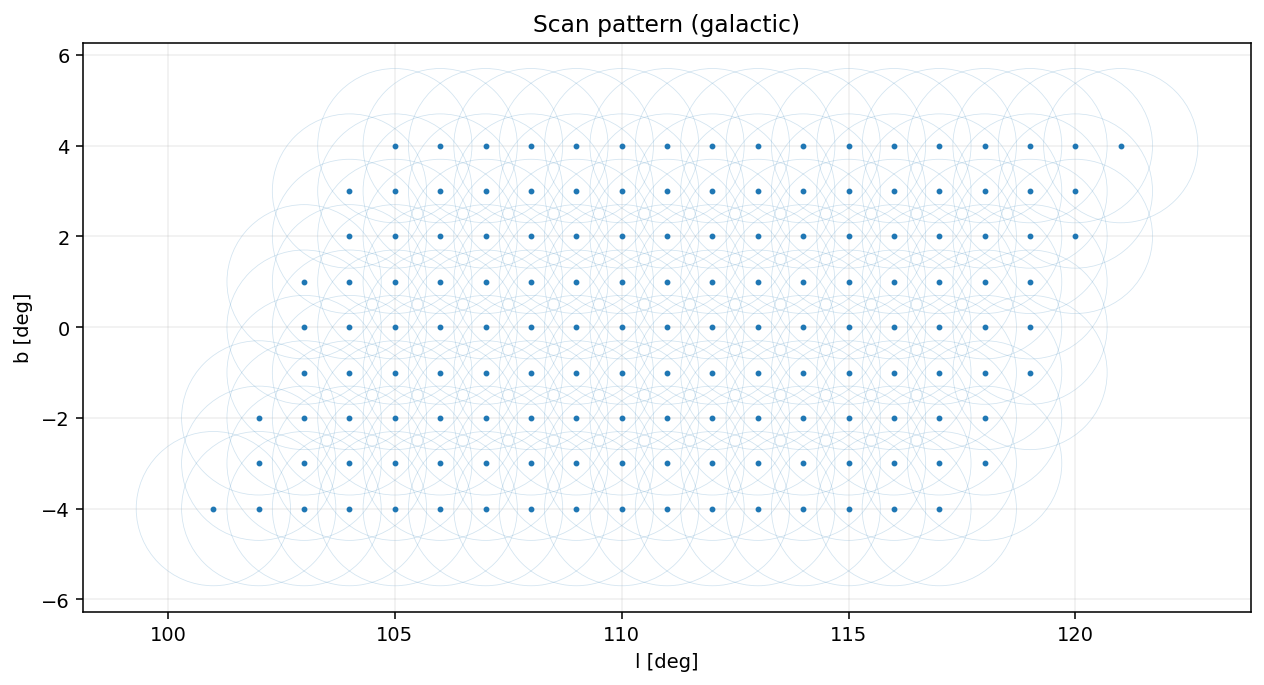

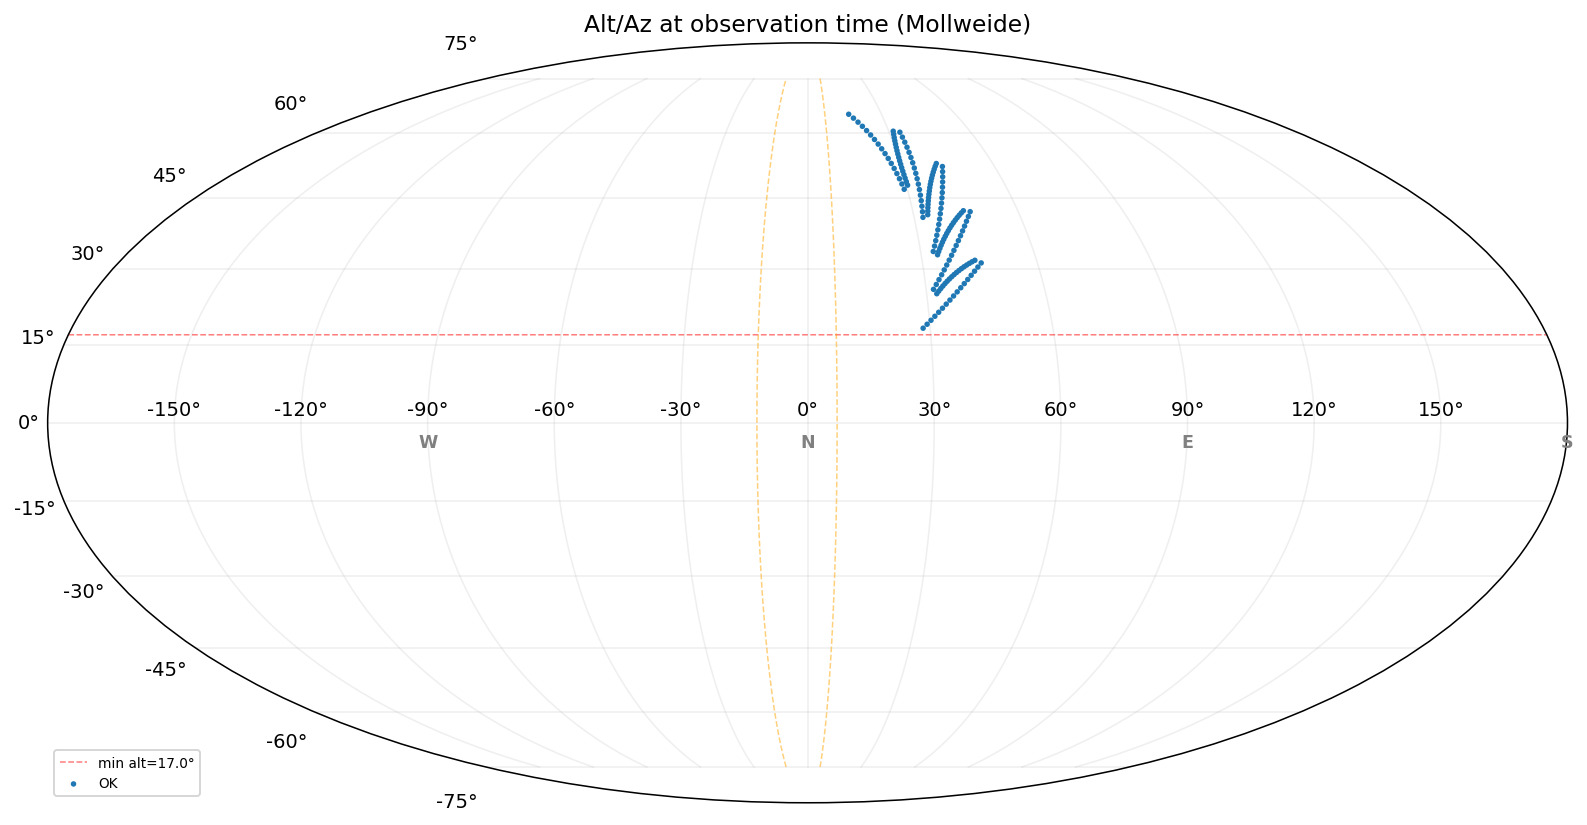

In [5]:
# --- Galactic coordinates (flat) ---
fig, ax = plt.subplots(figsize=(12, 5))
for s in sim:
    color = 'red' if s['bad'] else 'C0'
    beam = Circle((s['l'], s['b']), HPBW_DEG/2,
                  fill=False, edgecolor=color, alpha=0.2, lw=0.4)
    ax.add_patch(beam)
    ax.plot(s['l'], s['b'], 'o', color=color, ms=2)
ax.set_xlabel('l [deg]')
ax.set_ylabel('b [deg]')
ax.set_title('Scan pattern (galactic)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

# --- Alt/Az Mollweide ---
az_arr = np.array([s['az'] for s in sim])
alt_arr = np.array([s['alt'] for s in sim])
bad_arr = np.array([s['bad'] for s in sim])

# Mollweide: az in [-180, 180], centered on south (az=180)
az_moll = np.where(az_arr > 180, az_arr - 360, az_arr)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')
ax.grid(True, alpha=0.2)

# Horizon line
az_line = np.linspace(-np.pi, np.pi, 500)
ax.plot(az_line, np.full_like(az_line, np.deg2rad(MIN_ALT_DEG)),
        'r--', lw=0.8, alpha=0.5, label=f'min alt={MIN_ALT_DEG}°')

# Az exclusion zones
for az_lim in [AZ_MIN, AZ_MAX]:
    az_l = az_lim if az_lim <= 180 else az_lim - 360
    ax.axvline(np.deg2rad(az_l), color='orange', ls='--', lw=0.8, alpha=0.5)

# Plot pointings
good = ~bad_arr
ax.scatter(np.deg2rad(az_moll[good]), np.deg2rad(alt_arr[good]),
           s=8, color='C0', edgecolors='none', zorder=5, label='OK')
if bad_arr.any():
    ax.scatter(np.deg2rad(az_moll[bad_arr]), np.deg2rad(alt_arr[bad_arr]),
               s=15, color='red', marker='x', zorder=6, label='out of limits')

# Cardinal labels
for azd, name in [(0, 'N'), (90, 'E'), (180, 'S'), (-90, 'W')]:
    ax.annotate(name, (np.deg2rad(azd), np.deg2rad(-2)),
                fontsize=9, ha='center', va='top', fontweight='bold', color='gray')

ax.set_title('Alt/Az at observation time (Mollweide)')
ax.legend(fontsize=7, loc='lower left')
fig.tight_layout()
plt.show()

/tmp/ipykernel_1091377/2539518970.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


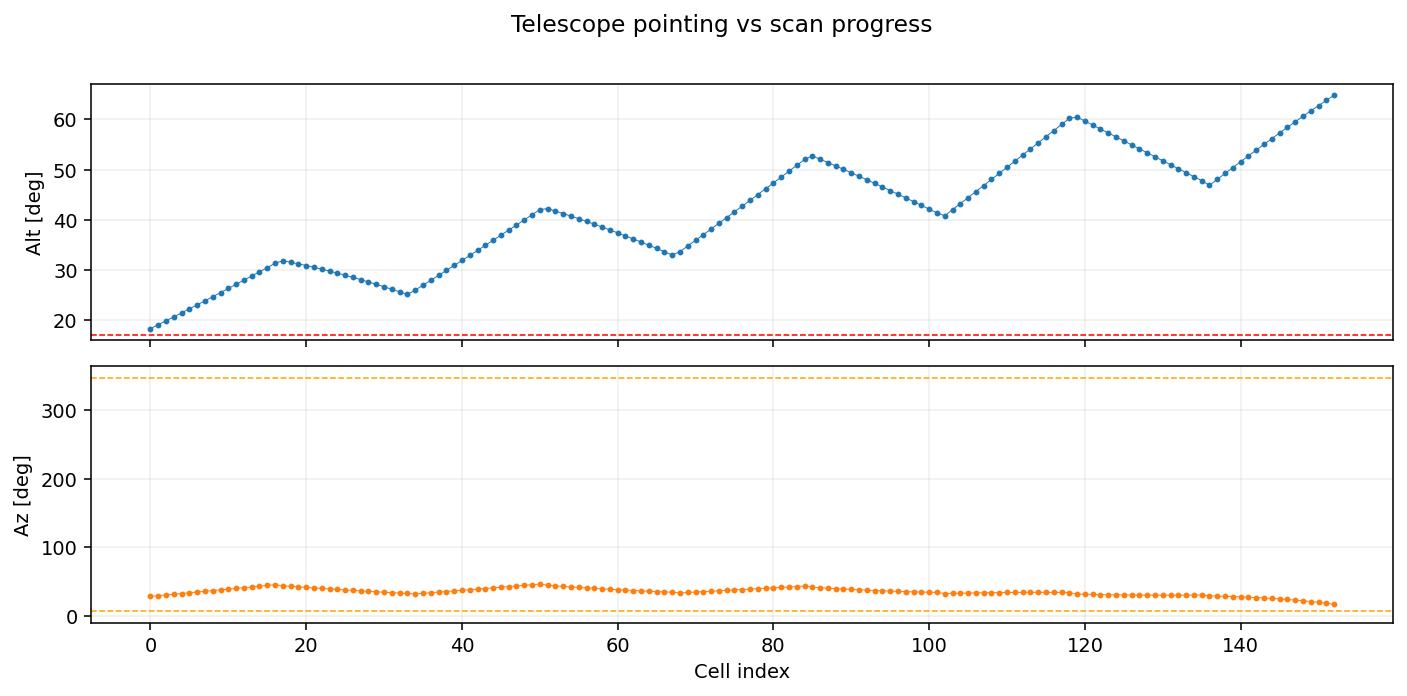

In [6]:
# Timeline: alt and az vs cell index
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True,
                                gridspec_kw={'hspace': 0.1})

idxs = [s['idx'] for s in sim]
ax1.plot(idxs, alts, 'o-', ms=2, lw=0.5, color='C0')
ax1.axhline(MIN_ALT_DEG, color='red', ls='--', lw=0.8)
ax1.set_ylabel('Alt [deg]')
ax1.grid(True, alpha=0.2)

ax2.plot(idxs, azs, 'o-', ms=2, lw=0.5, color='C1')
ax2.axhline(AZ_MIN, color='orange', ls='--', lw=0.8)
ax2.axhline(AZ_MAX, color='orange', ls='--', lw=0.8)
ax2.set_ylabel('Az [deg]')
ax2.set_xlabel('Cell index')
ax2.grid(True, alpha=0.2)

fig.suptitle('Telescope pointing vs scan progress')
fig.tight_layout()
plt.show()